# Synthea Claims Risk Model 

**Data sources**
- **[Synthea](https://synthea.mitre.org/)** — an open-source synthetic patient generator. All
  patients, encounters, and costs in this notebook are synthetic; no real patient or employer
  data is used anywhere in this project.
- **DOSM, *National Occupational Injury and Disease Statistics*** — published Malaysian
  government occupational injury rates by industry sector, used to calibrate the industry risk
  loadings in Section 7.

**Scope boundary:** this notebook produces an individual-level *loaded premium* per synthetic
employee.

## 1. Setup & Libraries

In [47]:
import pandas as pd
import numpy as np
import sqlite3
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import openpyxl
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.styles import Font, PatternFill

### Configuration

In [8]:
# Update this to point at your local Synthea CSV export folder.
DATA_DIR = "data/raw/"  # e.g. "C:/Users/you/Downlaods/data/raw/" if running locally

### Load the raw Synthea extract

Three tables: `patients` (demographics), `encounters` (the claims cost data), `observations` (coded clinical events, including smoking status).

In [9]:
patients = pd.read_csv(DATA_DIR + "patients.csv")
encounters = pd.read_csv(DATA_DIR + "encounters.csv")
observations = pd.read_csv(DATA_DIR + "observations.csv")

print("Files loaded successfully!")

Files loaded successfully!


## 2. Exploratory Data Profiling

### Patients table

In [ ]:
# Look at the first 5 rows of the patients table
patients.head()

In [ ]:
patients.info()

In [ ]:
patients.describe()

### Encounters table (claims cost)

In [ ]:
encounters.head()

In [ ]:
encounters.info()

In [ ]:
encounters.describe()

### Observations table (clinical events)

In [ ]:
observations.head()

In [ ]:
observations.info()

## 3. Preparing the Claims Window

In [10]:
# Converting 'START' column to Date
encounters['START'] = pd.to_datetime(encounters['START'])

# Finding the oldest and newest dates in the dataset
oldest_date = encounters['START'].min()
newest_date = encounters['START'].max()

print(f"The oldest encounter is from: {oldest_date}")
print(f"The newest encounter is from: {newest_date}")

The oldest encounter is from: 1919-02-03 11:30:07+00:00
The newest encounter is from: 2026-08-17 06:59:44+00:00


In [11]:
pd.isna(patients['DEATHDATE'])

0        True
1        True
2        True
3        True
4        True
        ...  
3422    False
3423     True
3424    False
3425    False
3426     True
Name: DEATHDATE, Length: 3427, dtype: bool

## 4. Building the Relational Layer (SQLite)

In [12]:
# Connect to a local SQLite database (creates the file if it doesn't exist)
conn = sqlite3.connect("eb_pricing.db")

# Reuse the DataFrames already loaded above instead of re-reading from disk.
patients.to_sql("patients", conn, if_exists="replace", index=False)
encounters.to_sql("encounters", conn, if_exists="replace", index=False)
observations.to_sql("observations", conn, if_exists="replace", index=False)


2812942

### Defining the Active Census

The snapshot date is set to '2026-01-01' where age is calculated and setting age limit between 18 and 65

count    1919.000000
mean       40.841063
std        13.785761
min        18.000000
25%        28.000000
50%        41.000000
75%        53.000000
max        65.000000
Name: age, dtype: float64


<Axes: >

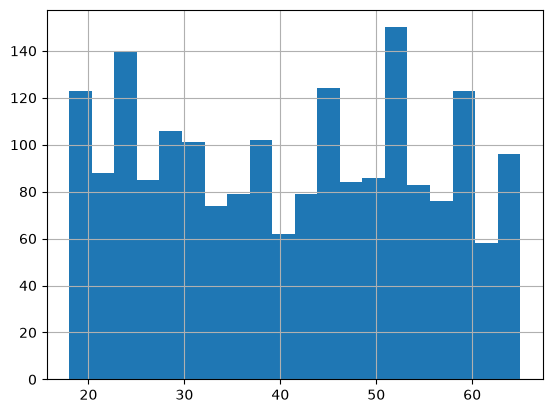

In [13]:
# Save active_census as a permanent View in SQLite
conn.execute("""
CREATE VIEW IF NOT EXISTS active_census AS
SELECT 
    Id AS patient_id,
    GENDER,
    BIRTHDATE,
    CAST((julianday('2026-01-01') - julianday(BIRTHDATE)) / 365.25 AS INT) AS age
FROM patients
WHERE DEATHDATE IS NULL 
  AND CAST((julianday('2026-01-01') - julianday(BIRTHDATE)) / 365.25 AS INT) BETWEEN 18 AND 65;
""")
conn.commit()

# Query the view to load the filtered census
query_census = "SELECT * FROM active_census;"
df_census = pd.read_sql(query_census, conn)

# View statistics and plot distribution
print(df_census['age'].describe())
df_census['age'].hist(bins=20)

## 5. Aggregating Historical Claims

Two versions follow: an early look at the raw multi-year shape of the data, and the corrected version that actually feeds the model.

### Original Approach

group claims by `claim_year`, producing many rows per patient (26,787 rows across ~1,919 patients in the original run).

In [14]:
# Querying claims using the newly created View
query_claims = """
SELECT 
    c.patient_id,
    c.age,
    c.GENDER,
    strftime('%Y', e.START) AS claim_year,
    COALESCE(SUM(e.TOTAL_CLAIM_COST), 0) AS total_claims
FROM active_census AS c
LEFT JOIN encounters AS e 
    ON c.patient_id = e.PATIENT
GROUP BY c.patient_id, c.age, c.GENDER, claim_year;
"""

df_result = pd.read_sql(query_claims, conn)
print(df_result.describe())
df_result.head(10)

                age   total_claims
count  26787.000000   26787.000000
mean      43.533841   10590.094611
std       13.659667   26112.717158
min       18.000000      75.000000
25%       32.000000     914.780000
50%       46.000000    1897.010000
75%       55.000000    6606.600000
max       65.000000  931032.930000


,patient_id,age,GENDER,claim_year,total_claims
0,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,1975,602.50
1,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,1992,704.20
2,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,1996,1061.68
3,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2005,1130.48
4,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2010,704.20
5,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2013,1033.63
6,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2014,914.78
7,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2016,704.20
8,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2017,1262.97
9,000d0ab4-8758-25f9-270d-4b9ac627bcc4,51,M,2018,704.20


## 6. Deriving Smoking Status from Clinical Observations

Smoking is a coded clinical observation (LOINC `72166-2`)

In [15]:
# Query distinct raw text entries for tobacco smoking status (LOINC 72166-2)
query_smoker_raw = """
SELECT DISTINCT VALUE
FROM observations
WHERE CODE = '72166-2';
"""

df_smoker_raw = pd.read_sql(query_smoker_raw, conn)
print(df_smoker_raw)

                            VALUE
0  Never smoked tobacco (finding)
1             Ex-smoker (finding)
2  Smokes tobacco daily (finding)


In [16]:
# Create or replace a view that maps patients to their smoking status
conn.execute("""
CREATE VIEW IF NOT EXISTS patient_smoker_status AS
SELECT 
    PATIENT AS patient_id,
    MAX(CASE WHEN VALUE = 'Smokes tobacco daily (finding)' THEN 1 ELSE 0 END) AS is_smoker
FROM observations
WHERE CODE = '72166-2'
GROUP BY PATIENT;
""")
conn.commit()

# Verify the binary distribution
df_smoker_dist = pd.read_sql("SELECT is_smoker, COUNT(*) as count FROM patient_smoker_status GROUP BY is_smoker;", conn)
print(df_smoker_dist)

   is_smoker  count
0          0   3360
1          1     67


> **Note:** ~2% of patients are flagged as daily smokers in this sample which is noticeably lower than typical real-world adult smoking prevalence (~15–20%). Worth keeping in mind when interpreting the smoker coefficient in Section 8.

### Single-policy-year panel (correct version)
Restrict to a single shared policy year — `POLICY_YEAR = 2025`, the last full calendar year before the snapshot and produce exactly **one row per patient**.

In [18]:
POLICY_YEAR = '2025'

query_final_panel = """
SELECT 
    c.patient_id,
    c.age,
    c.GENDER,
    COALESCE(s.is_smoker, 0) AS is_smoker,
    COALESCE(SUM(e.TOTAL_CLAIM_COST), 0) AS total_claims
FROM active_census c
LEFT JOIN patient_smoker_status s 
    ON c.patient_id = s.patient_id
LEFT JOIN encounters e 
    ON c.patient_id = e.PATIENT
    AND strftime('%Y', e.START) = ?
GROUP BY c.patient_id, c.age, c.GENDER, s.is_smoker;
"""

df_model_data = pd.read_sql(query_final_panel, conn, params=(POLICY_YEAR,))
print(f"Rows: {len(df_model_data)}  (one per active_census member -- was one per "
      f"patient-year before the fix)")
print(df_model_data.head())


Rows: 1919  (one per active_census member -- was one per patient-year before the fix)
                             patient_id  age GENDER  is_smoker  total_claims
0  000d0ab4-8758-25f9-270d-4b9ac627bcc4   51      M          0       4523.36
1  004ee5fe-4dec-030f-dd84-6217f57f04de   50      M          0      22253.80
2  00ec7649-20ca-53c9-39fd-7228cc2f3ec0   55      F          0       6759.84
3  00fdbb6b-68a7-3ca9-c54e-e0349500cb06   26      M          0       1152.42
4  01026cb4-ae34-6a5a-df71-f1d2ad04c94a   20      M          0          0.00


## 7. Malaysian Occupational Risk Calibration (DOSM Benchmark)

Applying the industry risk multiplier with real, published Malaysian occupational injury rates by sector (DOSM, national average 2.46 per 1,000 workers), banded into four occupational risk classes.

In [19]:
# Reconstructed DOSM Occupational Injury Benchmark (Source: Table 2.b - Jumlah Column)
# National Average Rate = 2.46 per 1,000 workers
dosm_data = {
    "industry_sector": [
        "Hotels and Restaurants",
        "Services",
        "Wholesale and Retail Trades",
        "Agriculture, Forestry and Fishing",
        "Utilities",
        "Transport, Storage and Communication",
        "Mining and Quarrying",
        "Finance, Insurance, Real Estate and Business Services",
        "Manufacturing",
        "Construction"
    ],
    "dosm_injury_rate_per_1k": [0.48, 1.14, 1.31, 1.64, 2.75, 2.79, 2.84, 2.97, 3.98, 4.19],
    "occupational_class": [
        "Class 1", "Class 1", "Class 1", 
        "Class 2", "Class 2", "Class 2", 
        "Class 3", "Class 3", 
        "Class 4", "Class 4"
    ],
    "risk_multiplier": [0.80, 0.85, 0.90, 0.95, 1.05, 1.05, 1.15, 1.20, 1.40, 1.50]
}

df_dosm = pd.DataFrame(dosm_data)

# Write to CSV and persist directly to your SQLite database
df_dosm.to_csv("dosm_industry_risk.csv", index=False)
df_dosm.to_sql("dosm_industry_risk", conn, if_exists="replace", index=False)

print(df_dosm)

                                     industry_sector  dosm_injury_rate_per_1k  \
0                             Hotels and Restaurants                     0.48   
1                                           Services                     1.14   
2                        Wholesale and Retail Trades                     1.31   
3                  Agriculture, Forestry and Fishing                     1.64   
4                                          Utilities                     2.75   
5               Transport, Storage and Communication                     2.79   
6                               Mining and Quarrying                     2.84   
7  Finance, Insurance, Real Estate and Business S...                     2.97   
8                                      Manufacturing                     3.98   
9                                       Construction                     4.19   

  occupational_class  risk_multiplier  
0            Class 1             0.80  
1            Class 1        

### First-pass industry loading (superseded below)

This early version applies the DOSM risk multiplier directly to the raw historical `total_claims`. Kept to show the iteration and superseded in Section 9, which applies the multiplier to the model's *predicted* baseline instead.

In [20]:
# Randomly assign a DOSM industry sector to each member
industries = df_dosm['industry_sector'].values
df_model_data['industry_sector'] = np.random.choice(industries, size=len(df_model_data))

# Join the DOSM risk multipliers into your dataset
df_model_data = df_model_data.merge(
    df_dosm[['industry_sector', 'risk_multiplier']], 
    on='industry_sector', 
    how='left'
)

# Apply occupational loading factor to GLM expected baseline claim
df_model_data['loaded_premium'] = df_model_data['total_claims'] * df_model_data['risk_multiplier']

## 8. Fitting the Actuarial Baseline Model (Poisson GLM)

In [21]:
# Prepare data and convert GENDER to a binary dummy variable
df_model_data['is_female'] = (df_model_data['GENDER'] == 'F').astype(int)

# Fit an actuarial Poisson GLM for expected claims
glm_formula = "total_claims ~ age + is_female + is_smoker"
glm_model = smf.glm(formula=glm_formula, data=df_model_data, family=sm.families.Poisson()).fit()

# Print the model summary coefficients
print(glm_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           total_claims   No. Observations:                 1919
Model:                            GLM   Df Residuals:                     1915
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.8543e+07
Date:                Fri, 21 Aug 2026   Deviance:                   5.7069e+07
Time:                        07:17:42   Pearson chi2:                 2.31e+08
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.1387      0.001   1.31e+04      0.0

## 9. Applying the Corrected Industry and Employer Group Loading

The DOSM multiplier applied to `pred_base_claims` (the model's individual-level prediction), not the raw historical value. This keeps individual risk (the GLM) and portfolio-level risk (the DOSM multiplier) separate. 

In [61]:
# Predict baseline claims from the Poisson GLM
df_model_data['pred_base_claims'] = glm_model.predict(df_model_data)

# Assign simulated corporate industry sectors
np.random.seed(42)
industries = df_dosm['industry_sector'].values
df_model_data['industry_sector'] = np.random.choice(industries, size=len(df_model_data))

# Direct dictionary mapping (avoids merge/duplicate column errors)
dosm_map = dict(zip(df_dosm['industry_sector'], df_dosm['risk_multiplier']))
df_model_data['risk_multiplier'] = df_model_data['industry_sector'].map(dosm_map)

# Calculate Final Actuarial Group Premium
df_model_data['final_loaded_premium'] = df_model_data['pred_base_claims'] * df_model_data['risk_multiplier']

# Verify top rows
print(df_model_data[['patient_id', 'age', 'is_smoker', 'industry_sector', 'pred_base_claims', 'risk_multiplier', 'final_loaded_premium']].head())

                             patient_id  age  is_smoker  \
0  000d0ab4-8758-25f9-270d-4b9ac627bcc4   51          0   
1  004ee5fe-4dec-030f-dd84-6217f57f04de   50          0   
2  00ec7649-20ca-53c9-39fd-7228cc2f3ec0   55          0   
3  00fdbb6b-68a7-3ca9-c54e-e0349500cb06   26          0   
4  01026cb4-ae34-6a5a-df71-f1d2ad04c94a   20          0   

                                     industry_sector  pred_base_claims  \
0                               Mining and Quarrying       6472.466471   
1                  Agriculture, Forestry and Fishing       6518.755212   
2  Finance, Insurance, Real Estate and Business S...      18108.554033   
3                                          Utilities       7734.663093   
4                               Mining and Quarrying       8072.547023   

   risk_multiplier  final_loaded_premium  
0             1.15           7443.336441  
1             0.95           6192.817452  
2             1.20          21730.264840  
3             1.05          

Simulating Employer Groups (Company_ID)

In [62]:
np.random.seed(7)  # separate seed stream from the industry assignment (seed=42)

n_employees = len(df_model_data)
MIN_GROUP_SIZE = 5  # insurers generally won't quote a standalone group below this

company_sizes = []
running_total = 0
while running_total < n_employees:
    size = int(np.random.lognormal(mean=3.0, sigma=1.1))
    size = max(size, MIN_GROUP_SIZE)
    if running_total + size > n_employees:
        size = n_employees - running_total  # trim the last group to exactly fill the census
    company_sizes.append(size)
    running_total += size

# Merge a too-small final group into the previous one rather than leaving an
# under-minimum standalone company.
if len(company_sizes) > 1 and company_sizes[-1] < MIN_GROUP_SIZE:
    company_sizes[-2] += company_sizes.pop()

n_companies = len(company_sizes)
company_ids = [f"COMP_{i+1:04d}" for i in range(n_companies)]

# Repeat each Company_ID by its group size, then shuffle so membership isn't
# correlated with row order (e.g. patient_id sequence).
assignment = np.repeat(company_ids, company_sizes)
np.random.shuffle(assignment)
df_model_data['Company_ID'] = assignment

print(f"Generated {n_companies} synthetic employer groups covering {n_employees} lives")
print(df_model_data.groupby('Company_ID').size().describe())

Generated 51 synthetic employer groups covering 1919 lives
count     51.000000
mean      37.627451
std       49.593129
min        5.000000
25%        8.500000
50%       19.000000
75%       36.500000
max      238.000000
dtype: float64


## 10. Validating the Model Visually

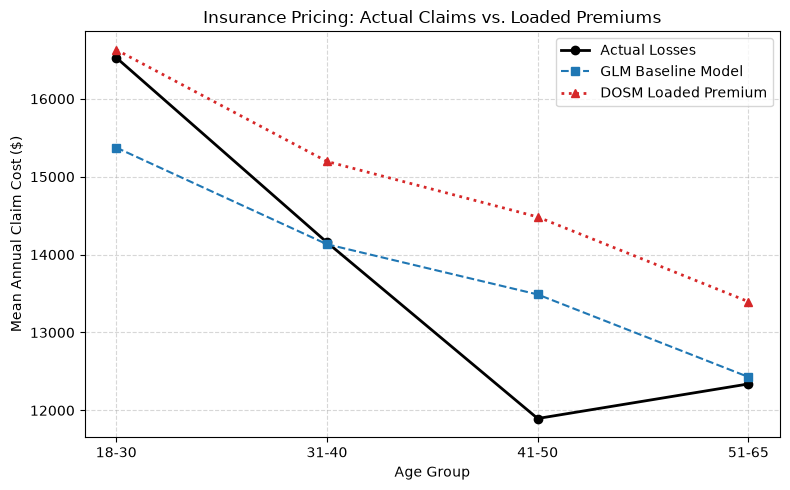

In [52]:
# Group members into actuarial age bands
df_model_data['age_group'] = pd.cut(
    df_model_data['age'], 
    bins=[17, 30, 40, 50, 65], 
    labels=['18-30', '31-40', '41-50', '51-65']
)

# Aggregate mean costs per age bracket
chart_data = df_model_data.groupby('age_group', observed=False)[
    ['total_claims', 'pred_base_claims', 'final_loaded_premium']
].mean()

# Plot Actuals vs Baseline vs Loaded Premium
plt.figure(figsize=(8, 5))
plt.plot(chart_data.index, chart_data['total_claims'], label='Actual Losses', marker='o', color='black', linewidth=2)
plt.plot(chart_data.index, chart_data['pred_base_claims'], label='GLM Baseline Model', linestyle='--', marker='s', color='#1f77b4')
plt.plot(chart_data.index, chart_data['final_loaded_premium'], label='DOSM Loaded Premium', linestyle=':', marker='^', color='#d62728', linewidth=2)

plt.title('Insurance Pricing: Actual Claims vs. Loaded Premiums')
plt.xlabel('Age Group')
plt.ylabel('Mean Annual Claim Cost ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save chart image for README inclusion
plt.savefig('actual_vs_predicted_claims.png', dpi=300)
plt.show()

## 11. Benchmarking Against a Flexible ML Model (XGBoost)

In [53]:
features = ['age', 'is_female', 'is_smoker']
X = df_model_data[features]
y = df_model_data['total_claims']

# XGBoost, Poisson objective -- same distributional assumption as the GLM baseline,
# isolates the effect of model flexibility alone.
xgb_model_poisson = xgb.XGBRegressor(
    objective='count:poisson', n_estimators=100, learning_rate=0.05,
    max_depth=3, random_state=42
)
xgb_model_poisson.fit(X, y)
df_model_data['pred_xgb_poisson_claims'] = xgb_model_poisson.predict(X)

# XGBoost, Tweedie objective -- correctly-specified distribution, var_power matches
# the GLM Tweedie in Section 12 so the two Tweedie models are comparable too.
xgb_model_tweedie = xgb.XGBRegressor(
    objective='reg:tweedie', tweedie_variance_power=1.2, n_estimators=100,
    learning_rate=0.05, max_depth=3, random_state=42
)
xgb_model_tweedie.fit(X, y)
df_model_data['pred_xgb_tweedie_claims'] = xgb_model_tweedie.predict(X)

glm_rmse = root_mean_squared_error(y, df_model_data['pred_base_claims'])
xgb_poisson_rmse = root_mean_squared_error(y, df_model_data['pred_xgb_poisson_claims'])
xgb_tweedie_rmse = root_mean_squared_error(y, df_model_data['pred_xgb_tweedie_claims'])
glm_mae = mean_absolute_error(y, df_model_data['pred_base_claims'])
xgb_poisson_mae = mean_absolute_error(y, df_model_data['pred_xgb_poisson_claims'])
xgb_tweedie_mae = mean_absolute_error(y, df_model_data['pred_xgb_tweedie_claims'])

print(f"GLM Poisson      -> RMSE: ${glm_rmse:,.2f} | MAE: ${glm_mae:,.2f}")
print(f"XGBoost Poisson  -> RMSE: ${xgb_poisson_rmse:,.2f} | MAE: ${xgb_poisson_mae:,.2f}")
print(f"XGBoost Tweedie  -> RMSE: ${xgb_tweedie_rmse:,.2f} | MAE: ${xgb_tweedie_mae:,.2f}")

GLM Poisson      -> RMSE: $34,343.77 | MAE: $15,324.60
XGBoost Poisson  -> RMSE: $33,238.86 | MAE: $14,631.82
XGBoost Tweedie  -> RMSE: $33,026.19 | MAE: $14,418.84


## 12. Distributional Fit Check — Tweedie GLM

In [54]:
tweedie_formula = "total_claims ~ age + is_female + is_smoker"
tweedie_model = smf.glm(
    formula=tweedie_formula, data=df_model_data,
    family=sm.families.Tweedie(var_power=1.2, link=sm.families.links.Log()) #
).fit()

df_model_data['pred_tweedie_claims'] = tweedie_model.predict(df_model_data)

tweedie_rmse = root_mean_squared_error(y, df_model_data['pred_tweedie_claims'])
tweedie_mae = mean_absolute_error(y, df_model_data['pred_tweedie_claims'])

print(f"GLM Poisson      -> RMSE: ${glm_rmse:,.2f} | MAE: ${glm_mae:,.2f}")
print(f"GLM Tweedie      -> RMSE: ${tweedie_rmse:,.2f} | MAE: ${tweedie_mae:,.2f}")
print(f"XGBoost Poisson  -> RMSE: ${xgb_poisson_rmse:,.2f} | MAE: ${xgb_poisson_mae:,.2f}")
print(f"XGBoost Tweedie  -> RMSE: ${xgb_tweedie_rmse:,.2f} | MAE: ${xgb_tweedie_mae:,.2f}")

GLM Poisson      -> RMSE: $34,343.77 | MAE: $15,324.60
GLM Tweedie      -> RMSE: $34,389.20 | MAE: $15,334.16
XGBoost Poisson  -> RMSE: $33,238.86 | MAE: $14,631.82
XGBoost Tweedie  -> RMSE: $33,026.19 | MAE: $14,418.84


## 13. Model Comparison Visualization

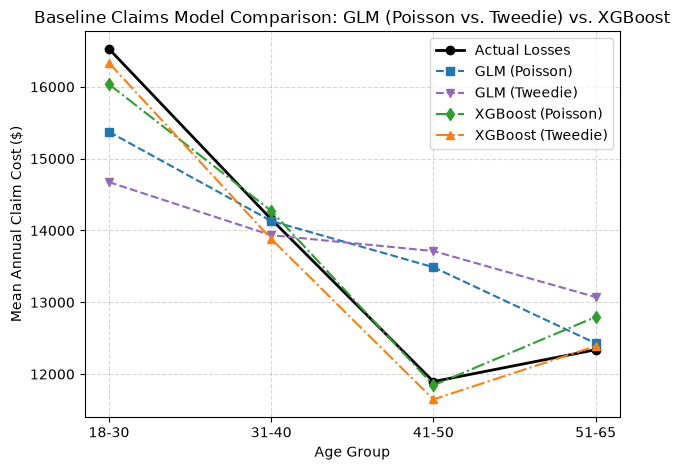

In [55]:
# Aggregate mean actuals and predictions across age groups
chart_comp = df_model_data.groupby('age_group', observed=False)[
    ['total_claims', 'pred_base_claims', 'pred_tweedie_claims',
     'pred_xgb_poisson_claims', 'pred_xgb_tweedie_claims']
].mean()

plt.plot(chart_comp.index, chart_comp['total_claims'], label='Actual Losses', marker='o', color='black', linewidth=2)
plt.plot(chart_comp.index, chart_comp['pred_base_claims'], label='GLM (Poisson)', linestyle='--', marker='s', color='#1f77b4')
plt.plot(chart_comp.index, chart_comp['pred_tweedie_claims'], label='GLM (Tweedie)', linestyle='--', marker='v', color='#9467bd')
plt.plot(chart_comp.index, chart_comp['pred_xgb_poisson_claims'], label='XGBoost (Poisson)', linestyle='-.', marker='d', color='#2ca02c')
plt.plot(chart_comp.index, chart_comp['pred_xgb_tweedie_claims'], label='XGBoost (Tweedie)', linestyle='-.', marker='^', color='#ff7f0e')

plt.title('Baseline Claims Model Comparison: GLM (Poisson vs. Tweedie) vs. XGBoost')
plt.xlabel('Age Group')
plt.ylabel('Mean Annual Claim Cost ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save image for GitHub portfolio
plt.savefig('glm_vs_xgboost_comparison.png', dpi=300)
plt.show()


> **Note:** all four models above are fit and scored on the same data, with no train/test split. XGBoost's edge over both GLMs may partly reflect its greater flexibility fitting training-set noise rather than genuine generalization. This doesn't affect the notebook's pricing output, which uses GLM Poisson's `pred_base_claims` (Sections 8–9), not XGBoost — XGBoost here is a benchmark only.

## 14. Rescaling to Malaysian Ringgit

In [63]:
RM_TARGET_MEAN = 1800

rm_scale_factor = RM_TARGET_MEAN / df_model_data['final_loaded_premium'].mean()
df_model_data['final_loaded_premium_rm'] = df_model_data['final_loaded_premium'] * rm_scale_factor

print(f"Scale factor applied: {rm_scale_factor:.6f}")
print(df_model_data['final_loaded_premium_rm'].describe())

# Export the member-level output ready for the Excel quote schedule stage
export_cols = ['patient_id', 'Company_ID', 'age', 'GENDER', 'is_smoker', 'industry_sector',
               'risk_multiplier', 'final_loaded_premium_rm']
df_model_data[export_cols].to_csv('member_level_pricing_output.csv', index=False)
print("\nWrote member_level_pricing_output.csv -- ready for the Excel quote schedule stage.")


Scale factor applied: 0.120533
count    1919.000000
mean     1800.000000
std       958.413208
min       568.895685
25%       894.637805
50%      1803.139453
75%      2527.532639
max      4544.266664
Name: final_loaded_premium_rm, dtype: float64

Wrote member_level_pricing_output.csv -- ready for the Excel quote schedule stage.
